In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

feature_names = data.feature_names
target_names = data.target_names

In [2]:
print(f"Numero di campioni: {X.shape[0]}")
print(f"Numero di feature: {X.shape[1]}")
print(f"Feature names: {data.feature_names}")
print(f"\nDistribuzione classi:")
print(f"   - Classe 0 (Maligno): {np.sum(y == 0)} campioni")
print(f"   - Classe 1 (Benigno): {np.sum(y == 1)} campioni")

Numero di campioni: 569
Numero di feature: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Distribuzione classi:
   - Classe 0 (Maligno): 212 campioni
   - Classe 1 (Benigno): 357 campioni


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set: {X_test.shape[0]} campioni")

Training set: 398 campioni
Test set: 171 campioni


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
tree_gini.fit(X_train, y_train)

pred_train = tree_gini.predict(X_train)
pred_test = tree_gini.predict(X_test)

print(f"Accuracy: {accuracy_score(y_train, pred_train):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_test):.4f}")

Accuracy: 0.9950
Accuracy: 0.9298


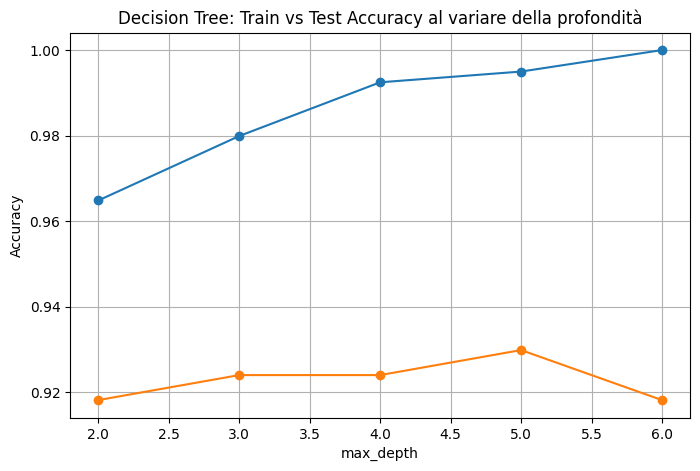

In [5]:
import matplotlib.pyplot as plt

depths = [x for x in range(2,7)]

train_acc = []
test_acc = []

for depth in depths :
    tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=42)
    tree_gini.fit(X_train, y_train)

    pred_train = tree_gini.predict(X_train)
    pred_test = tree_gini.predict(X_test)

    train_acc.append(accuracy_score(y_train, pred_train))
    test_acc.append(accuracy_score(y_test, pred_test))

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker='o', label="Train Accuracy")
plt.plot(depths, test_acc, marker='o', label="Test Accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Test Accuracy al variare della profondità")
plt.grid(True)
plt.show()

In [6]:
def bootstrap_sample (X, y, random_state = None) :
    n_samples = X.shape[0]

    if random_state is not None :
        np.random.seed(random_state)

    # Campionamento con reinserimento
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X[indices]
    y_boot = y[indices]

    # Indici out-of-bag
    oob_indices = np.array(list(set(range(n_samples)) - set(indices)))

    return X_boot, y_boot, indices, oob_indices 

In [7]:
n_samples_demo = 20

X_temp = np.array([x for x in range(n_samples_demo)])
y_temp = np.array([x for x in range(n_samples_demo)])

print(X_temp)
print(y_temp)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [8]:
print(f"Dimensione dataset originale: {n_samples_demo}")

for i in range(3) :
    _, _, indices, oob_indices = bootstrap_sample(X_temp, y_temp, random_state=i)
    unique_indices = np.unique(indices)
    print(f"\nBootstrap sample: {i+1}:")
    print(f"   Indici nel campione: {sorted(indices)}")
    print(f"   Elementi unici: {len(unique_indices)}")
    print(f"   Out-of-bag indices: {sorted(oob_indices)}")

Dimensione dataset originale: 20

Bootstrap sample: 1:
   Indici nel campione: [np.int64(0), np.int64(1), np.int64(3), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(8), np.int64(9), np.int64(12), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19)]
   Elementi unici: 16
   Out-of-bag indices: [np.int64(2), np.int64(10), np.int64(11), np.int64(16)]

Bootstrap sample: 2:
   Indici nel campione: [np.int64(0), np.int64(1), np.int64(5), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(11), np.int64(11), np.int64(12), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(18), np.int64(18)]
   Elementi unici: 14
   Out-of-bag indices: [np.int64(2), np.int64(3), np.int64(4), np.int64(14), np.int64(17), np.int64(19)]

Bootstrap sample: 3:
   Indici nel campione: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int6

In [9]:
n_samples_demo = 10000

X_temp = np.array([x for x in range(n_samples_demo)])
y_temp = np.array([x for x in range(n_samples_demo)])

unique_percentages = []
oob_percentages = []

for i in range(1000) :
    _, _, indices, oob_indices = bootstrap_sample(X_temp, y_temp, random_state=i)
    unique_indices = np.unique(indices)

    n_unique = len(unique_indices)
    n_oob = len(oob_indices)

    unique_pct = (n_unique / n_samples_demo) * 100
    oob_pct = (n_oob / n_samples_demo) * 100

    unique_percentages.append(unique_pct)
    oob_percentages.append(oob_pct)

# Calcolo medie e deviazioni
mean_unique = np.mean(unique_percentages)
std_unique = np.std(unique_percentages)
mean_oob = np.mean(oob_percentages)
std_oob = np.std(oob_percentages)

print(f"Media valori unici: {mean_unique:.2f}%")
print(f"Std valori unici: {std_unique:.2f}%")

print(f"Media OOB: {mean_oob:.2f}%")
print(f"Std OOB: {std_oob:.2f}%")

Media valori unici: 63.19%
Std valori unici: 0.31%
Media OOB: 36.81%
Std OOB: 0.31%


In [10]:
def train_bagging_ensemble (X, y, n_estimators=10, max_depth=5, criterion="gini", random_state=42) :
    # Impostiamo il seed
    np.random.seed(random_state)

    ensemble = []
    oob_indices_list = []

    for i in range(n_estimators) :
        # Bootstrap sampling
        X_boot, y_boot, _, oob_indices = bootstrap_sample(X, y)

        tree = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=random_state)
        tree.fit(X_boot, y_boot)

        ensemble.append(tree)
        oob_indices_list.append(oob_indices)

    return ensemble, oob_indices_list

In [11]:
ensemble_bagging, oob_indices = train_bagging_ensemble(X_train, y_train, max_depth=5)

In [12]:
from collections import Counter

def predict_bagging_ensemble (ensemble, X) :
    # Ottieni predizioni di ogni albero
    predictions = np.array([tree.predict(X) for tree in ensemble])

    # Voto di maggioranza
    y_pred = np.array([Counter(col).most_common(1)[0][0] for col in predictions.T])

    return y_pred

In [13]:
y_pred_bagging = predict_bagging_ensemble(ensemble_bagging, X_test)
print(f"Test Accuracy bagging: {accuracy_score(y_test, y_pred_bagging):.4f}")

Test Accuracy bagging: 0.9357


In [14]:
single_tree = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
single_tree.fit(X_train, y_train)

y_pred_single_tree = single_tree.predict(X_test)
print(f"Test Accuracy single tree: {accuracy_score(y_test, y_pred_single_tree):.4f}")

Test Accuracy single tree: 0.9298


In [15]:
def compute_oob_error (ensemble, X, y, oob_indices_list) :
    oob_predictions = []
    oob_targets = []

    for tree, oob_indices in zip(ensemble, oob_indices_list) :
        if len(oob_indices) > 0 :
            X_oob = X[oob_indices]
            y_oob = y[oob_indices]
            y_pred_oob = tree.predict(X_oob)

            oob_predictions.extend(y_pred_oob)
            oob_targets.extend(y_oob)

    oob_error = 1 - accuracy_score(oob_targets, oob_predictions)
    return oob_error, accuracy_score(oob_targets, oob_predictions)

In [16]:
# OOB Error
oob_error, oob_acc = compute_oob_error(ensemble_bagging, X_train, y_train, oob_indices)

In [17]:
print(f"OOB Accuracy: {oob_acc:.4f}")
print(f"OOB Error: {oob_error:.4f}")

OOB Accuracy: 0.9307
OOB Error: 0.0693


In [18]:
n_features_total = X_train.shape[1]
n_features_classification = int(np.sqrt(n_features_total))

print (f"Numero totale di feature: {n_features_total}")
print (f"Suggerito per classificazione (√p): {n_features_classification}")

Numero totale di feature: 30
Suggerito per classificazione (√p): 5


In [19]:
def train_random_forest (X, y, n_estimators=100, max_depth=5, criterion="gini", random_state=42) :
    # calcoliamo automaticamente il numero di features
    n_features = X.shape[1]
    n_features_per_split = int(np.sqrt(n_features))

    np.random.seed(random_state)

    forest = []
    oob_indices_list = []

    for i in range(n_estimators) :
        # Bootstrap sampling
        # Impostiamo il seed a random_state + i in modo che tutti gli alberi abbiano seed diversi
        X_boot, y_boot, boot_indices, oob_indices = bootstrap_sample(X, y)

        # Training dell'albero
        # passiamo max_features=n_features_per_split, l'albero internamente gestirà la situazione delle features
        tree = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, max_features=n_features_per_split, random_state=random_state+i)
        tree.fit(X_boot, y_boot)

        forest.append(tree)
        oob_indices_list.append(oob_indices)

    return forest, oob_indices_list

In [20]:
forest, _ = train_random_forest(X_train, y_train)

In [21]:
def predict_random_forest (forest, X) :
    predictions = np.array([tree.predict(X) for tree in forest])
    # Voto di maggioranza
    y_pred = np.array([Counter(col).most_common(1)[0][0] for col in predictions.T])
    return y_pred

In [22]:
# Predizioni
y_pred_rf = predict_random_forest(forest, X_test)
print (f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Test Accuracy: 0.9415


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Training
rf_skl = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_skl.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
pred_test = rf_skl.predict(X_test)
print (f"Test Accuracy: {accuracy_score(y_test, pred_test):.4f}")

Test Accuracy: 0.9415


In [25]:
importances = rf_skl.feature_importances_
indices = np.argsort(importances)[::-1]

for idx in indices :
    print (f"{feature_names[idx]}: {importances[idx]:.4f}")

worst concave points: 0.1638
worst area: 0.1525
worst perimeter: 0.0870
mean radius: 0.0781
worst radius: 0.0758
mean perimeter: 0.0756
mean concave points: 0.0631
mean concavity: 0.0553
mean area: 0.0426
worst concavity: 0.0319
worst compactness: 0.0243
area error: 0.0220
worst smoothness: 0.0143
worst symmetry: 0.0130
mean compactness: 0.0128
radius error: 0.0110
worst texture: 0.0102
worst fractal dimension: 0.0096
perimeter error: 0.0092
mean smoothness: 0.0087
mean texture: 0.0071
concavity error: 0.0063
fractal dimension error: 0.0046
concave points error: 0.0040
smoothness error: 0.0034
mean symmetry: 0.0033
mean fractal dimension: 0.0028
compactness error: 0.0027
texture error: 0.0025
symmetry error: 0.0024


In [26]:
from sklearn.datasets import load_diabetes

# Diabetes: predire la progressione della malattia da 10 misure fisiologiche
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target

print (f"Numero di campioni: {X_reg.shape[0]}")
print (f"Numero di feature: {X_reg.shape[1]}")
print (f"Feature names: {diabetes.feature_names}")

Numero di campioni: 442
Numero di feature: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [27]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print (f"Training set: {X_train_reg.shape[0]} campioni")
print (f"Test set: {X_test_reg.shape[0]} campioni")

Training set: 309 campioni
Test set: 133 campioni


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=10, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

predictions = rf_regressor.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, predictions)
print (f"Mean Squared Error: {mse}")

mae = mean_absolute_error(y_test_reg, predictions)
print (f"Mean Absolute Error: {mae}")

Mean Squared Error: 3230.2555639097745
Mean Absolute Error: 45.74812030075188


In [30]:
from sklearn.tree import DecisionTreeRegressor

# Train del singolo albero di regressione
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_regressor.fit(X_train_reg, y_train_reg)

# Predizione
dt_predictions = dt_regressor.predict(X_test_reg)

# Metriche
dt_mse = mean_squared_error(y_test_reg, dt_predictions)
dt_mae = mean_absolute_error(y_test_reg, predictions)

print (f"Mean Squared Error: {dt_mse}")
print (f"Mean Absolute Error: {dt_mae}")

Mean Squared Error: 3818.0714941788437
Mean Absolute Error: 45.74812030075188
